In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nhts_data = pd.read_csv('Project3_Data/NHTS(in).csv')
ngsim_data = pd.read_csv('Project3_Data/NGSIM(in).csv')

<Figure size 1000x600 with 0 Axes>

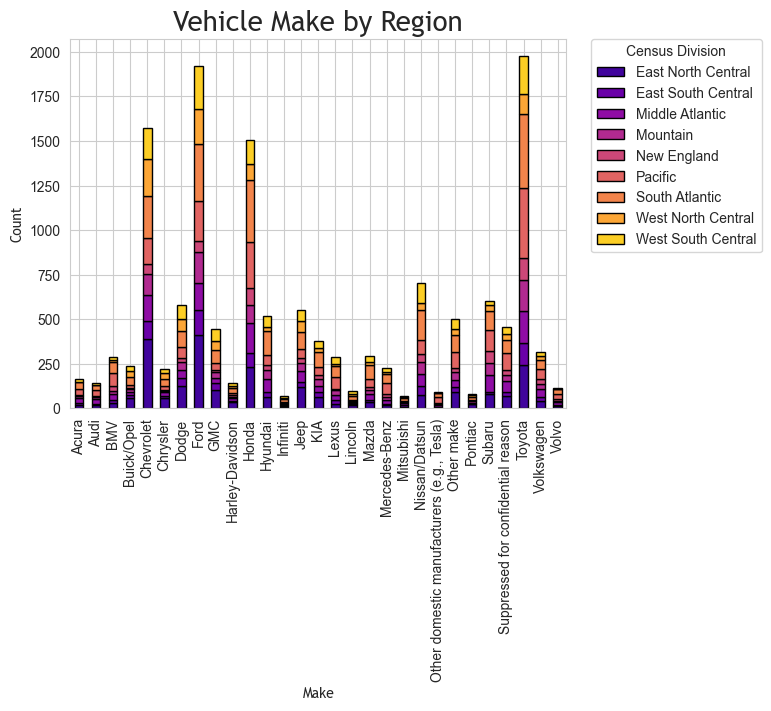

In [40]:
# Filter out NA values (assuming NA represents missing values)
nhts_data = nhts_data.dropna(subset = ['make'])

# Grouping and counting by 'make' and 'census_division'
data_grouped = nhts_data.groupby(['make', 'census_division']).size().unstack(fill_value = 0)

# Plotting
plt.figure(figsize = (10,6))

# Plotting stacked bar chart
data_grouped.plot(kind = 'bar', stacked = True, edgecolor = 'black', color = sns.color_palette('plasma', len(data_grouped.columns)))

# Customizing the plot
plt.xlabel('Make', fontname = 'Trebuchet MS')
plt.ylabel('Count', fontname = 'Trebuchet MS')
plt.title('Vehicle Make by Region', fontname = 'Trebuchet MS', fontsize = 20)

# Moving the legend outside the bounds of the plot
plt.legend(title = 'Census Division', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

#Show the plot
plt.show()

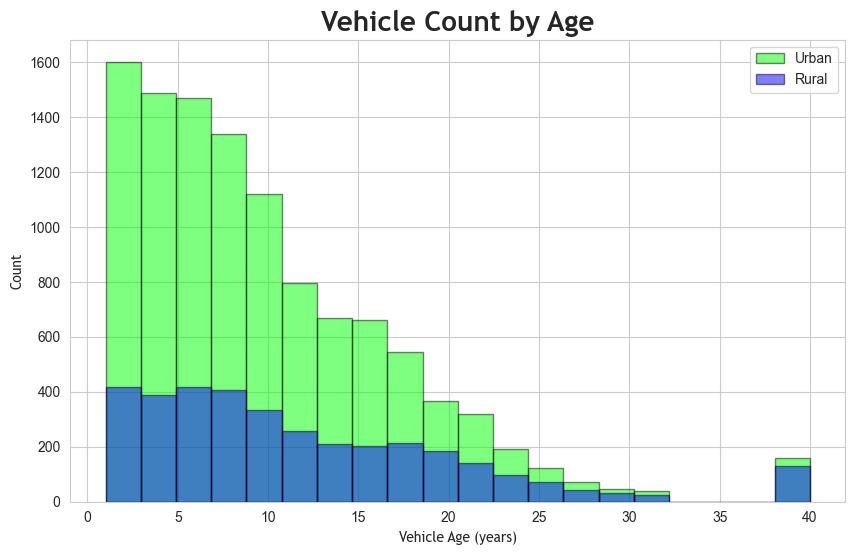

In [8]:
## Step 1: tell Python you are making a figure
plt.figure(figsize = (10,6))

## Step 2: filter and plot Urban vehicle ages
# hint: use nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
# use the alpha argument to make bars semi-transparent (e.g., alpha=0.5)
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
           
plt.hist(urban_ages, bins = 20, alpha = .5, label = 'Urban', color = 'lime', edgecolor = 'black',)

## Step 3: filter and plot Rural vehicle ages on the same figure
plt.hist(rural_ages, bins = 20, alpha = .5, label = 'Rural', color = 'blue', edgecolor = 'black')

## Step 4: add labels, title, and legend
plt.xlabel('Vehicle Age (years)', fontname = 'Trebuchet MS')
plt.ylabel('Count', fontname = 'Trebuchet MS')
plt.title('Vehicle Count by Age', fontname = 'Trebuchet MS', fontsize = 20, weight = 'bold')
plt.legend()


<Figure size 1400x800 with 0 Axes>

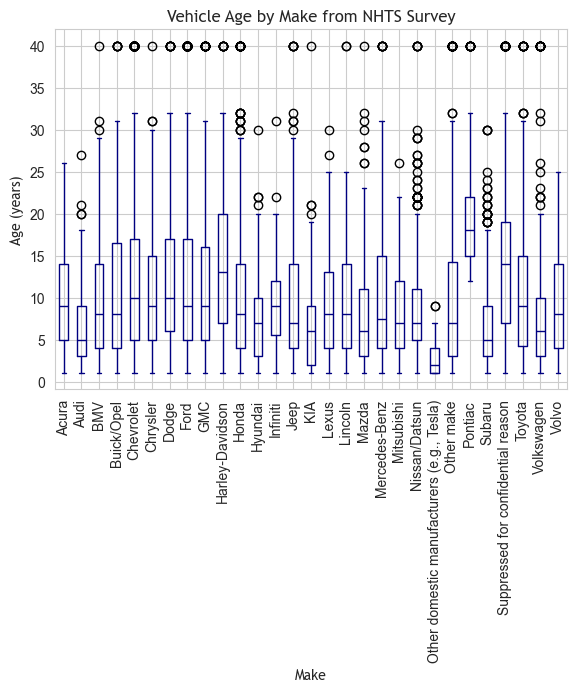

In [45]:
## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (14,8))

## Step 2: call the type of plot and tell the function what variables you want to plot
nhts_data.boxplot(column = 'vehicle_age', by = 'make', color = 'navy', )

## Step 3: add customization to the plot
plt.xticks(rotation=90)

### this line rotates your labels on the x-axis by 90 so they are easy to read

### the next two lines create your axis labels
plt.xlabel('Make', fontname = 'Trebuchet MS')
plt.ylabel('Age (years)', fontname = 'Trebuchet MS')


### this line gives your plot a title
plt.title('Vehicle Age by Make from NHTS Survey', fontname = 'Trebuchet MS')
plt.suptitle('')

## Step 4: tell python to show the plot
plt.show()

In [17]:
trajectory_number = 7 # vehicle pair x

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

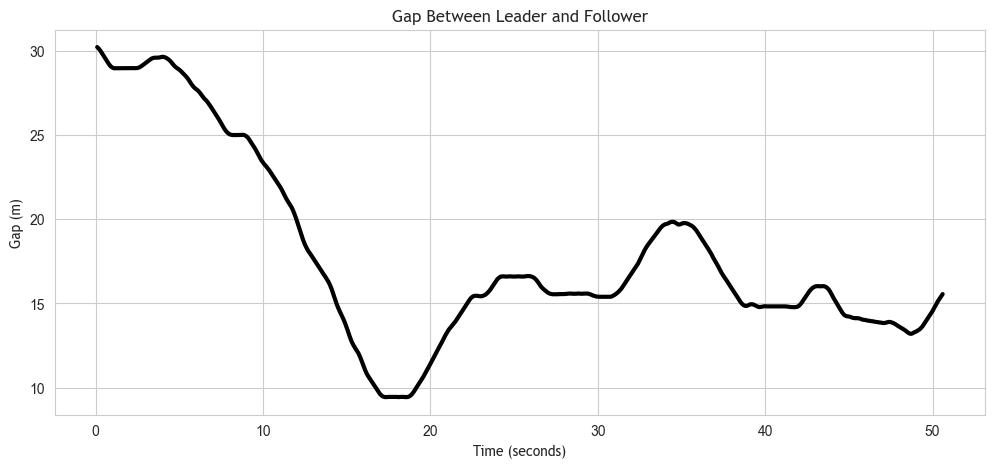

In [38]:
# Now try to plot the gap distance between two vehicle pairs. Gap = position of leader - position of follower
# Plot the gap distance over time 
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

plt.figure(figsize = (12,5))
plt.plot(data_subset['Time'], gap_distance, color = 'black', linewidth = 3)

plt.xlabel('Time (seconds)', fontname = 'Trebuchet MS')
plt.ylabel('Gap (m)', fontname = 'Trebuchet MS')
plt.title('Gap Between Leader and Follower', fontname = 'Trebuchet MS')


plt.show()

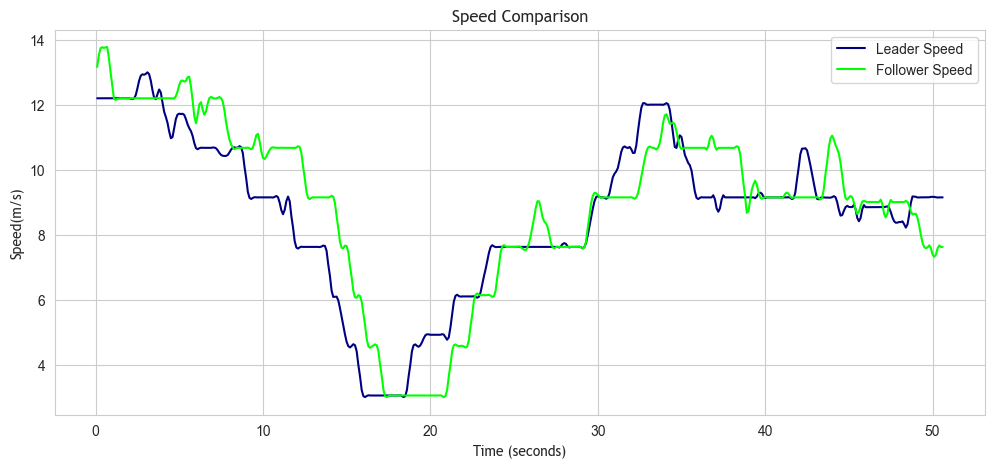

In [21]:
plt.figure(figsize = (12,5))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_speed(m/s)', label = 'Leader Speed', color = 'navy')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_speed(m/s)', label = 'Follower Speed', color = 'lime')

plt.xlabel('Time (seconds)', fontname = 'Trebuchet MS')
plt.ylabel('Speed(m/s)', fontname = 'Trebuchet MS')
plt.title('Speed Comparison', fontname = 'Trebuchet MS')

plt.legend()
plt.show()

In [23]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    
    
    return acceleration

In [35]:
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_acc = data_subset['leader_acc(m/s^2)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1

In [27]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]        #this makes the starting value [0] same as the follower vehicle speed

In [28]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]
    
    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]* dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]*dt
print("Simulation complete.")

Simulation complete.


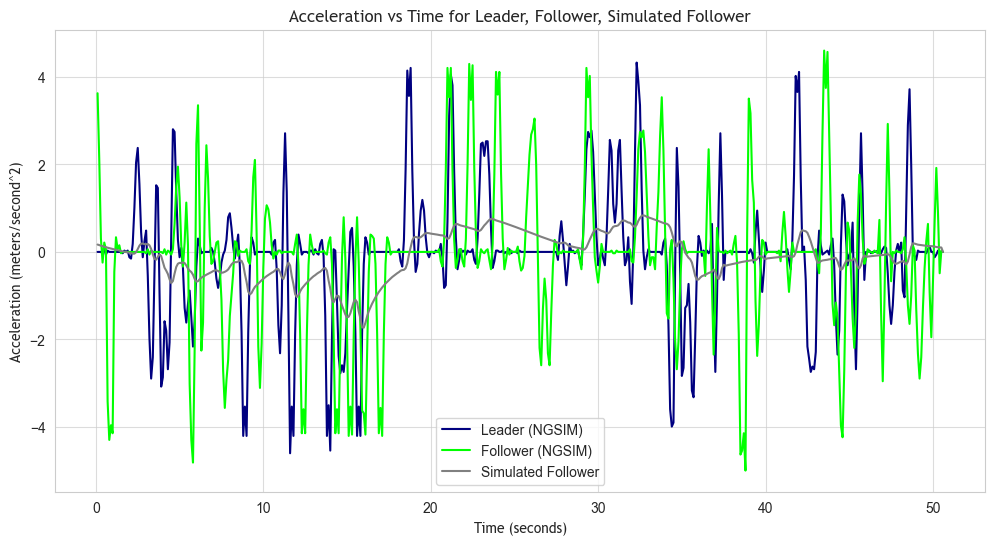

In [46]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_acc, label = 'Leader (NGSIM)', color = 'navy')
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, label = 'Follower (NGSIM)', color = 'lime')
plt.plot(time_data, sim_acc, label = 'Simulated Follower', color = 'grey')

plt.xlabel('Time (seconds)', fontname = 'Trebuchet MS')
plt.ylabel('Acceleration (meters/second^2)', fontname = 'Trebuchet MS')
plt.title('Acceleration vs Time for Leader, Follower, Simulated Follower', fontname = 'Trebuchet MS')
plt.legend()
plt.grid(True, alpha = .67)
plt.show()